1. Data Setup & Base Cleaning

In [24]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeRegressor, export_text
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

# Load your dataset (ensure the CSV is uploaded to your Colab session)
df = pd.read_csv('/content/Used_Car_Sales_dataset.xlsx - Sheet1.csv')
print(df.columns.tolist())


['dateCrawled', 'name', 'seller', 'offerType', 'price', 'abtest', 'vehicleType', 'yearOfRegistration', 'gearbox', 'powerPS', 'model', 'kilometer', 'monthOfRegistration', 'fuelType', 'brand', 'notRepairedDamage', 'dateCreated', 'nrOfPictures', 'postalCode', 'Lattitude', 'Longitude', 'lastSeen']


In [25]:
# 1. Check Missing Values
print("--- Missing Values ---")
print(df.isnull().sum())

# 2. Check Outliers
print("\n--- Descriptive Statistics ---")
display(df[['price', 'yearOfRegistration', 'powerPS', 'kilometer']].describe())

# 3. Check Unique Value
print("\n--- Unique Values in Categorical Columns ---")
for col in ['vehicleType', 'gearbox', 'fuelType', 'notRepairedDamage']:
    print(f"{col}: {df[col].unique()}")

# 4. Check number of cars having price = 0 or wrong registeredyear
zero_price = (df['price'] == 0).sum()
invalid_year = ((df['yearOfRegistration'] < 1900) | (df['yearOfRegistration'] > 2016)).sum()
print(f"\nNumber of cars having price = 0: {zero_price}")
print(f"Number of cars having wrong registeredyear (>2016 or <1900): {invalid_year}")

--- Missing Values ---
dateCrawled                0
name                      15
seller                     0
offerType                  0
price                      0
abtest                     0
vehicleType            37854
yearOfRegistration         0
gearbox                20202
powerPS                    0
model                  20475
kilometer                  0
monthOfRegistration        0
fuelType               33377
brand                      0
notRepairedDamage      72028
dateCreated                0
nrOfPictures               0
postalCode                 0
Lattitude                  0
Longitude                  0
lastSeen                   0
dtype: int64

--- Descriptive Statistics ---


,price,yearOfRegistration,powerPS,kilometer
count,3.714040e+05,371404.000000,371404.000000,371404.000000
mean,1.730085e+04,2004.578788,115.539528,125618.962101
std,3.588553e+06,92.881853,191.786025,40111.605815
min,0.000000e+00,1000.000000,0.000000,5000.000000
25%,1.150000e+03,1999.000000,70.000000,125000.000000
50%,2.950000e+03,2003.000000,105.000000,150000.000000
75%,7.200000e+03,2008.000000,150.000000,150000.000000
max,2.147484e+09,9999.000000,20000.000000,150000.000000



--- Unique Values in Categorical Columns ---
vehicleType: ['limousine' 'kleinwagen' 'cabrio' nan 'kombi' 'coupe' 'andere' 'bus'
 'suv']
gearbox: ['manuell' 'automatik' nan]
fuelType: ['benzin' 'diesel' nan 'lpg' 'hybrid' 'andere' 'elektro' 'cng']
notRepairedDamage: ['nein' nan 'ja']

Number of cars having price = 0: 10776
Number of cars having wrong registeredyear (>2016 or <1900): 14736


In [26]:
# 1. Start fresh from your original dataframe
df_clean = df.copy()

# 2. Drop absolute duplicate rows
initial_rows = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Dropped {initial_rows - len(df_clean)} duplicate rows.")

# 3. Apply your foundational domain filters (Price & Year)
df_clean = df_clean[(df_clean['price'] >= 100) & (df_clean['price'] <= 150000)]
df_clean = df_clean[(df_clean['yearOfRegistration'] >= 1900) & (df_clean['yearOfRegistration'] <= 2016)]

# 4. Filter secondary illogical outliers (Horsepower)
# A typical passenger car has between 50 and 800 PS.
df_clean = df_clean[(df_clean['powerPS'] >= 50) & (df_clean['powerPS'] <= 800)]

# 5. Handle Missing Values (Nulls)
# Let's check exactly where your missing data is before we decide how to handle it
print("\nMissing values per column:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

# 6. Recalculate Liquidity Speed on the clean dataset
df_clean['dateCreated'] = pd.to_datetime(df_clean['dateCreated'], format='mixed')
df_clean['lastSeen'] = pd.to_datetime(df_clean['lastSeen'], format='mixed')
df_clean['liquidity_speed_days'] = (df_clean['lastSeen'] - df_clean['dateCreated']).dt.days

print(f"\nFinal clean rows ready for analysis: {len(df_clean)}")

Dropped 80 duplicate rows.

Missing values per column:
name                     9
vehicleType          10561
gearbox               4997
model                11121
fuelType             14950
notRepairedDamage    41778
dtype: int64

Final clean rows ready for analysis: 306061


2. Finding thresholds base on 3 different methods

In [27]:
# --- 1. STATISTICAL METHOD (Quantiles) ---
print("--- 1. STATISTICAL METHOD (Distribution) ---")
# Let's check where the data naturally breaks into equal thirds, and where the top 10% starts
quantiles = df_clean['price'].quantile([0.33, 0.66, 0.90])
print(f"Bottom 33% of cars end at: ${quantiles[0.33]:.2f}")
print(f"Middle 33% of cars end at: ${quantiles[0.66]:.2f}")
print(f"Top 10% of cars start at: ${quantiles[0.90]:.2f}\n")

# --- 2. UNSUPERVISED METHOD (K-Means Clustering) ---
print("--- 2. UNSUPERVISED METHOD (K-Means Clustering) ---")
# This algorithm groups the prices into 3 tiers by mathematically minimizing the variance
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# We use double brackets [['price']] because scikit-learn expects a 2D array
df_clean['cluster'] = kmeans.fit_predict(df_clean[['price']])

# Calculate the minimum and maximum price for each mathematical cluster
cluster_boundaries = df_clean.groupby('cluster')['price'].agg(['min', 'max', 'count']).sort_values('min')
print("K-Means Price Tiers:")
print(cluster_boundaries)
print("\n")

# --- 3. SUPERVISED METHOD (Decision Tree) ---
print("--- 3. SUPERVISED METHOD (Decision Tree) ---")
# This algorithm finds the exact price point that causes the biggest change in liquidity speed
# First, we drop any rows missing liquidity data just to be safe
dt_data = df_clean.dropna(subset=['price', 'liquidity_speed_days'])

X = dt_data[['price']]
y = dt_data['liquidity_speed_days']

# We limit the depth to 2 so we only see the most massive, important splits
tree_model = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_model.fit(X, y)

# Print the visual rules of the tree to see the exact thresholds
tree_rules = export_text(tree_model, feature_names=['price'])
print("Decision Tree Liquidity Splits:")
print(tree_rules)

--- 1. STATISTICAL METHOD (Distribution) ---
Bottom 33% of cars end at: $1990.00
Middle 33% of cars end at: $5999.00
Top 10% of cars start at: $15000.00

--- 2. UNSUPERVISED METHOD (K-Means Clustering) ---
K-Means Price Tiers:
           min     max   count
cluster                       
0          100    9380  241373
1         9385   30750   59391
2        30790  150000    5297


--- 3. SUPERVISED METHOD (Decision Tree) ---
Decision Tree Liquidity Splits:
|--- price <= 5549.50
|   |--- price <= 2886.50
|   |   |--- value: [7.72]
|   |--- price >  2886.50
|   |   |--- value: [8.93]
|--- price >  5549.50
|   |--- price <= 10305.00
|   |   |--- value: [10.07]
|   |--- price >  10305.00
|   |   |--- value: [11.33]



**Market Segmentation Rationale**  
The Business Problem: Defining "Budget" versus "Premium" vehicles based on subjective assumptions (like a static $15,000 threshold) introduces analytical bias. This can lead to misaligned product features, ineffective seller retention strategies, and wasted marketing spend.

The Analytical Methodology: To eliminate human bias and let the data dictate the market boundaries, multiple machine learning approaches were utilized: Unsupervised Learning (K-Means clustering to evaluate price geometry) and Supervised Learning (Decision Tree regressor to isolate variance in liquidity speed).

The Unified Finding: Both independent models converged to disprove the initial $15k hypothesis. K-Means clustering grouped the largest market volume (over 241,000 vehicles) into a segment capping at $9,380. Simultaneously, the Decision Tree proved that crossing the $10,305 mark causes a definitive spike in days-to-sell (jumping from 10.07 to 11.33 days).

The Commercial Impact: The convergence of these models proves that the platform's true "mass market" boundary sits around the $10,000 mark. Consequently, any product interventions aimed at accelerating liquidity or defending against free competitors must be heavily targeted at inventory priced under $10,000.

3. Analyzing The Trust Bottleneck

In [28]:
# 1. Filter the > $10,000 vehicle segment (Premium Delay Group)
df_premium = df_clean[df_clean['price'] > 10000].copy()

# 2. Analyze liquidity speed based on reported damage
trust_analysis = df_premium.groupby('notRepairedDamage').agg(
    total_vehicles=('name', 'count'),
    avg_days_to_sell=('liquidity_speed_days', 'mean')
).round(2).sort_values('avg_days_to_sell', ascending=False)

print("Trust Bottleneck Analysis (Cars > $10,000):")
print(trust_analysis)

Trust Bottleneck Analysis (Cars > $10,000):
                   total_vehicles  avg_days_to_sell
notRepairedDamage                                  
nein                        53084             11.35
ja                            986              9.34


/tmp/ipykernel_2078/2228482181.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_premium, x='notRepairedDamage', y='liquidity_speed_days', palette='Set2')


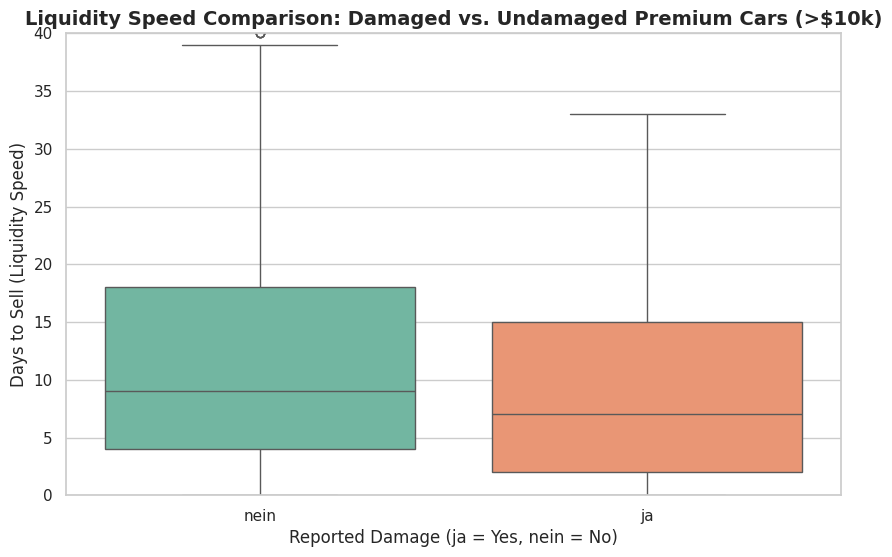

In [29]:
# Set a professional style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plot the distribution of sales duration for cars > $10k based on damage status
sns.boxplot(data=df_premium, x='notRepairedDamage', y='liquidity_speed_days', palette='Set2')
plt.title('Liquidity Speed ​​Comparison: Damaged vs. Undamaged Premium Cars (>$10k)', fontsize=14, fontweight='bold')
plt.xlabel('Reported Damage (ja = Yes, nein = No)', fontsize=12)
plt.ylabel('Days to Sell (Liquidity Speed)', fontsize=12)
plt.ylim(0, 40) # Trim outliers for better visualization
plt.show()

In [30]:
# Tách nhóm
premium_damaged = df_premium[df_premium['notRepairedDamage'] == 'ja']['liquidity_speed_days'].dropna()
premium_undamaged = df_premium[df_premium['notRepairedDamage'] == 'nein']['liquidity_speed_days'].dropna()

# Chạy kiểm định
stat, p_value = stats.mannwhitneyu(premium_damaged, premium_undamaged, alternative='less')

print(f"P-Value: {p_value:.5f}")
if p_value < 0.05:
    print("Conclusion: Broken cars sell faster, a statistically significant finding. The insight has been successfully validated!")
else:
    print("Conclusion: The difference may be due to chance.")

P-Value: 0.00000
Conclusion: Broken cars sell faster, a statistically significant finding. The insight has been successfully validated!


In [31]:
# 1. Filter vehicles that are BOTH expensive (> $10k) AND damaged ('ja')
df_premium_damaged = df_clean[(df_clean['price'] > 10000) & (df_clean['notRepairedDamage'] == 'ja')]

# 2. Group by brand to see which damaged brands are bought the most
brand_flippers = df_premium_damaged.groupby('brand').agg(
    total_vehicles=('name', 'count'),
    avg_days_to_sell=('liquidity_speed_days', 'mean')
).sort_values('total_vehicles', ascending=False)

# 3. Display the Top 10 brands to verify the hypothesis
print("Top 10 Most Purchased Damaged Brands > $10,000:")
print(brand_flippers.head(10))

Top 10 Most Purchased Damaged Brands > $10,000:
                total_vehicles  avg_days_to_sell
brand                                           
bmw                        214          8.593458
mercedes_benz              198          8.904040
audi                       169          9.497041
volkswagen                 164          9.219512
ford                        39         10.923077
porsche                     33          7.363636
skoda                       23          7.608696
sonstige_autos              14          9.357143
toyota                      11          8.090909
nissan                      11         13.363636


4. Analyzing Temporal, Spatial, Risk Classification

In [32]:
# Ensure the dateCreated column is datetime (if not already run)
df_clean['dateCreated'] = pd.to_datetime(df_clean['dateCreated'], format='mixed')
df_clean['listing_month'] = df_clean['dateCreated'].dt.month

print("--- 1. TEMPORAL INSIGHT (Seasonality) ---")
# Filter Cabrio (convertible) and SUV vehicles
df_season = df_clean[df_clean['vehicleType'].isin(['cabrio', 'suv'])]
seasonal_liquidity = df_season.groupby(['vehicleType', 'listing_month'])['liquidity_speed_days'].mean().unstack()
print("Average selling time by listing month (Cabrio vs SUV):")
print(seasonal_liquidity.round(2))
print("\n" + "="*50 + "\n")


print("--- 2. SPATIAL INSIGHT (Hotspots for cars > $10k) ---")
df_premium = df_clean[df_clean['price'] > 10000]
# Calculate listing volume and liquidity speed by postal code
geo_liquidity = df_premium.groupby('postalCode').agg(
    total_listings=('name', 'count'),
    avg_days_to_sell=('liquidity_speed_days', 'mean')
)
# Only consider areas with high transaction volume (>= 50 cars) to avoid noise
geo_hotspots = geo_liquidity[geo_liquidity['total_listings'] >= 50].sort_values('avg_days_to_sell')
print("Top 5 FASTEST premium car absorption areas:")
print(geo_hotspots.head(5).round(2))
print("\nTop 5 SLOWEST premium car absorption areas:")
print(geo_hotspots.tail(5).round(2))
print("\n" + "="*50 + "\n")


print("--- 3. INVENTORY RISK INSIGHT (Stuck rate > 14 days) ---")
# Define "Stuck Inventory" as cars taking more than 14 days to sell
df_clean['is_stuck'] = df_clean['liquidity_speed_days'] > 14

# Check if gearbox type affects inventory risk
risk_by_gearbox = df_clean.groupby('gearbox').agg(
    total_cars=('name', 'count'),
    stuck_cars=('is_stuck', 'sum')
)
risk_by_gearbox['stuck_rate_%'] = (risk_by_gearbox['stuck_cars'] / risk_by_gearbox['total_cars'] * 100).round(2)
print("Stuck inventory rate by gearbox type:")
print(risk_by_gearbox.sort_values('stuck_rate_%', ascending=False))

--- 1. TEMPORAL INSIGHT (Seasonality) ---
Average selling time by listing month (Cabrio vs SUV):
listing_month     1      2      3     4      8      10     11    12
vehicleType                                                        
cabrio         61.86  39.40  11.74  2.64  241.5    NaN  121.0  97.0
suv            63.29  37.04  11.17  2.59    NaN  152.0  144.0   NaN


--- 2. SPATIAL INSIGHT (Hotspots for cars > $10k) ---
Top 5 FASTEST premium car absorption areas:
            total_listings  avg_days_to_sell
postalCode                                  
10115                  450              0.35
60311                   79              1.84
38518                   71             10.99
94315                   52             11.29
65428                  100             11.31

Top 5 SLOWEST premium car absorption areas:
            total_listings  avg_days_to_sell
postalCode                                  
38440                   67             12.30
50259                   63          

4. Predictive Modeling

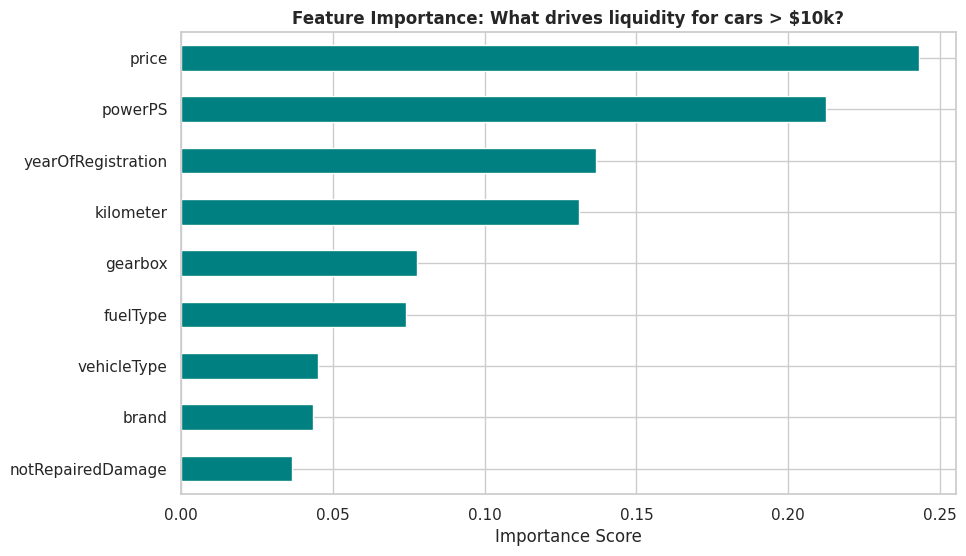

In [33]:
ml_df = df_premium.copy().dropna(subset=['liquidity_speed_days'])
categorical_cols = ['vehicleType', 'gearbox', 'fuelType', 'brand', 'notRepairedDamage']

le = LabelEncoder()
for col in categorical_cols:
    ml_df[col] = le.fit_transform(ml_df[col].astype(str))

features = ['price', 'yearOfRegistration', 'powerPS', 'kilometer'] + categorical_cols
X = ml_df[features]
y = ml_df['liquidity_speed_days']

rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X, y)

importance = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=True)
plt.figure(figsize=(10, 6))
importance.plot(kind='barh', color='teal')
plt.title('Feature Importance: What drives liquidity for cars > $10k?', fontweight='bold')
plt.xlabel('Importance Score')
plt.show()

**1. Key Observations**
- Market Segmentation Boundary: Both Unsupervised Learning (K-Means) and Supervised Learning (Decision Tree) models converged to prove that the mass-market boundary ends at the $10,000 mark, disproving the initial $15,000 hypothesis. Vehicles priced above $10,000 experience a significant liquidity lag.

- Market Segmentation Boundary: Both Unsupervised (K-Means) and Supervised (Decision Tree) models converged to prove the mass-market boundary ends at $10,000, disproving the initial $15,000 hypothesis. Vehicles priced above $10,000 experience a significant liquidity lag.

- Macro Drivers of Liquidity: A Random Forest regressor identified price, horsepower (powerPS), registration year, and mileage as the primary global drivers of liquidity across the platform, heavily outweighing categorical features like brand or damage status in the aggregate model.

- The Condition Paradox: Within the premium segment (>$10,000), vehicles explicitly reported as damaged sold almost 2 days faster than undamaged vehicles.

- Niche Market Dominance: The leaderboard for high-priced, damaged vehicles is dominated by the German luxury trio (BMW, Mercedes-Benz, Audi). Notably, damaged Porsches clear the platform in an astonishing 7.36 days.

- Geographic Hotspots & Inventory Risk: Tech and financial hubs (e.g., postal codes 10115, 60311) absorb premium vehicles almost instantly. Additionally, automatic transmission vehicles carry a ~3% higher risk of becoming "stuck inventory" (>14 days) compared to manual vehicles.

**2. Business Insights**
- The Categorical Paradox (Macro vs. Micro): While core physical specifications (price, age, mileage) dictate overall market liquidity, categorical variables like damage status show low global feature importance but act as critical conversion drivers in micro-segments. This proves the necessity of highly targeted product strategies over a one-size-fits-all algorithm.
- The Trust Bottleneck: In higher price tiers, transparency drives liquidity. When sellers explicitly declare vehicle damage, it sets accurate buyer expectations and significantly shortens the negotiation phase.
- The "Flipper" Market: The rapid liquidity of damaged luxury cars reveals a strong niche user base: mechanics and car flippers seeking luxury vehicles for repair and arbitrage.
- Data Collection Bias: Time-series analysis revealed a massive volume of listings in early months with artificially inflated time-on-market metrics (60–240 days). This represents an artifact of the web scraping methodology rather than a genuine market trend.

**3. Actionable Recommendations**
- Algorithmic Valuation Tool: Leverage the top features identified by the Random Forest model (price, power, year, mileage) to build an automated "Suggested Price" calculator, helping everyday sellers price competitively for optimal liquidity.
- Product Features: Mandate a "Verified Condition" field for listings over $10,000. Disallow "Unknown" damage statuses to enforce transparency and accelerate platform-wide liquidity.

- Monetization & Ad-Sales:
    * Launch a paid "Mechanic Alerts" subscription, sending push notifications to flippers the moment a damaged luxury vehicle is listed.
    * Implement dynamic pricing for listing fees: charge higher rates for dealerships listing premium cars in geographic hotspots, capitalizing on the extreme local demand.
    * Seller Success: Build an automated "Risk Score" system. If a user lists an automatic vehicle above $10k, trigger a UI prompt suggesting they purchase a "Feature Ad" boost to mitigate the risk of the listing stalling.

**4. Limitations**
- Proxy Metrics: The liquidity_speed_days metric is calculated using the gap between the listing creation date and the last seen date. This is a proxy metric and does not reflect the exact contract signing date or final negotiated sale price.
- Missing Data Imputation: A large volume of missing categorical data was imputed as 'Unknown' to preserve overall market volume. While this provided valuable behavioral insights regarding concealed information, it limits the precision of the predictive models.